# RT-IDS: Real-Time Network Intrusion Detection for IoT
## PyTorch Deep Neural Network Baseline — CIC-IoT-2023 Dataset

Professional baseline covering all three canonical classification granularities used in the IDS literature:

- **2-class** — Benign vs Attack (inline real-time gate)
- **8-class** — Attack families (operational routing)
- **34-class** — Specific attack variants (forensic / paper-comparable)

**Best practices applied:**
1. Raw per-attack CSV ingestion; label derived from folder name (no null-label risk)
2. Per-class subsampling at ingest to cap majorities
3. Lazy Polars → Zstd-compressed Parquet (fast reloads, low memory)
4. Stratified 70/15/15 train/val/test split at **34-class granularity**
5. Identical row indices reused across all three tasks (fair comparison)
6. `RobustScaler` fit on train only (no test leakage)
7. Class-weighted Cross-Entropy loss (handles extreme imbalance)
8. Early stopping on **validation** loss
9. Per-mode per-class precision/recall/F1 + normalized confusion matrix
10. Unified comparison table across the three tasks

## Methodological Decisions (preempting standard committee critiques)

These four choices shape every result below. They are deliberate, defensible, and called out here so they are not surprises during defense:

1. **39-feature CIC-IoT-2023 release.** The official UNB CIC website distributes a 39-feature CSV version. Most published papers on this dataset use a 46-feature variant that is not available from the official source; results in this notebook will not be numerically directly comparable to those papers, and that is acknowledged as a scope decision rather than treated as a defect.
2. **Three split strategies, temporal as headline.** CIC-IoT-2023 flows captured ~50 ms apart in the same attack session look near-identical in the 39-feature representation. A pure random row split lets the model exploit within-session redundancy. We report **temporal** (per-folder, sort source CSVs, train on earliest 70%), **per-CSV** (`GroupShuffleSplit`), and **random** (parity with published numbers). Headline numbers are temporal. The gap between random and temporal quantifies session-level memorization on this dataset and is itself a finding.
3. **Random per-class subsampling with deduplication.** CIC-IoT-2023 contains ~24M exact duplicate rows out of ~46M. We `unique()` per attack folder before sampling, then random-sample to `MAX_ROWS_PER_CLASS` with a fixed seed. This is the dominant approach in the CIC-IoT-2023 literature; sequential `head()` sampling — used in earlier drafts — biases the model toward the opening minutes of each capture session.
4. **"Real-time" scoped to interactive single-flow inference, not line-rate.** The benchmark reports per-batch p50/p95/p99 and end-to-end latency including `scaler.transform`. The thesis claim is that latency is sufficient for an interactive demo (target <100 ms end-to-end). Line-rate gateway deployment (>1M flows/sec) is explicitly out of scope.

**Expected finding worth noting in advance:** the **Web** attack family (SQL injection, XSS, command injection, browser hijacking) is inherently weakly detectable from flow-level statistics alone — these are application-layer attacks and the 39 features describe transport-layer behavior. Lower per-class F1 on Web attacks, and Web↔Benign confusion in the 8-class matrix, is consistent with Neto et al. (2023) and is a property of the feature set, not a model failure.

In [14]:
import os
import time
from pathlib import Path

import numpy as np
import polars as pl
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
)

import joblib
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
DATASET_DIRECTORY = Path('data/CSV')
PARQUET_PATH = Path('data/cic_iot_2023.parquet')
MODELS_DIR = Path('models')
MODELS_DIR.mkdir(exist_ok=True)

MAX_ROWS_PER_CLASS = 200_000

X_COLUMNS = [
    'Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate',
    'fin_flag_number', 'syn_flag_number', 'rst_flag_number',
    'psh_flag_number', 'ack_flag_number', 'ece_flag_number',
    'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count',
    'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP',
    'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP',
    'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std',
    'Tot size', 'IAT', 'Number', 'Variance',
]
Y_COLUMN = 'Label'
N_FEATURES = len(X_COLUMNS)

FLAG_COLUMNS = [
    'fin_flag_number', 'syn_flag_number', 'rst_flag_number',
    'psh_flag_number', 'ack_flag_number', 'ece_flag_number',
    'cwr_flag_number', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP',
    'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP',
    'IPv', 'LLC',
]
LOG_COLUMNS = [c for c in X_COLUMNS if c not in FLAG_COLUMNS]

# Which classification tasks to train/evaluate.
# Use ['2'] while iterating; ['2', '8', '34'] for the full thesis run.
MODES_TO_RUN = ['2']

# Which split strategies to run.
# 'temporal'  — earliest CSVs train, latest CSVs test (headline; mirrors deployment)
# 'per_csv'   — GroupShuffleSplit on source CSV (no within-session leakage; temporal-agnostic)
# 'random'    — original row-level stratified split (for parity with published numbers)
# Use ['temporal'] while iterating; ['temporal', 'per_csv', 'random'] for the full thesis run.
SPLITS_TO_RUN = ['temporal']

BATCH_SIZE = 4096
N_EPOCHS = 50
PATIENCE = 5
LR = 1e-3
SEED = 42

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
np.random.seed(SEED)

print(f'Features: {N_FEATURES} | log1p: {len(LOG_COLUMNS)} | flags: {len(FLAG_COLUMNS)}')
print(f'Per-class cap: {MAX_ROWS_PER_CLASS:,}')
print(f'Modes to run: {MODES_TO_RUN}')
print(f'Splits to run: {SPLITS_TO_RUN}')

Features: 39 | log1p: 17 | flags: 22
Per-class cap: 200,000
Modes to run: ['2']
Splits to run: ['temporal']


## Label Mappings

Three granularities derived from the 34 attack folders. Keys are **case-sensitive** and must match folder names exactly. An assert at ingest time catches unmapped folders.

In [16]:
DICT_8CLASSES = {
    # DDoS (12)
    'DDoS-ACK_Fragmentation': 'DDoS', 'DDoS-HTTP_Flood': 'DDoS',
    'DDoS-ICMP_Flood': 'DDoS', 'DDoS-ICMP_Fragmentation': 'DDoS',
    'DDoS-PSHACK_FLOOD': 'DDoS', 'DDoS-RSTFINFLOOD': 'DDoS',
    'DDoS-SlowLoris': 'DDoS', 'DDoS-SYN_Flood': 'DDoS',
    'DDoS-SynonymousIP_Flood': 'DDoS', 'DDoS-TCP_Flood': 'DDoS',
    'DDoS-UDP_Flood': 'DDoS', 'DDoS-UDP_Fragmentation': 'DDoS',
    # DoS (4)
    'DoS-HTTP_Flood': 'DoS', 'DoS-SYN_Flood': 'DoS',
    'DoS-TCP_Flood': 'DoS', 'DoS-UDP_Flood': 'DoS',
    # Mirai (3)
    'Mirai-greeth_flood': 'Mirai', 'Mirai-greip_flood': 'Mirai',
    'Mirai-udpplain': 'Mirai',
    # Recon (5)
    'Recon-HostDiscovery': 'Recon', 'Recon-OSScan': 'Recon',
    'Recon-PingSweep': 'Recon', 'Recon-PortScan': 'Recon',
    'VulnerabilityScan': 'Recon',
    # Spoofing (2)
    'DNS_Spoofing': 'Spoofing', 'MITM-ArpSpoofing': 'Spoofing',
    # Web (6)
    'Backdoor_Malware': 'Web', 'BrowserHijacking': 'Web',
    'CommandInjection': 'Web', 'SqlInjection': 'Web',
    'Uploading_Attack': 'Web', 'XSS': 'Web',
    # BruteForce (1)
    'DictionaryBruteForce': 'BruteForce',
    # Benign (1)
    'Benign_Final': 'Benign',
}

DICT_2CLASSES = {k: ('Benign' if v == 'Benign' else 'Attack') for k, v in DICT_8CLASSES.items()}

assert len(DICT_8CLASSES) == 34, f'Expected 34 folders, got {len(DICT_8CLASSES)}'
print(f'Mapped 34 folders → 8 families → 2 classes')
print(f'8-class families: {sorted(set(DICT_8CLASSES.values()))}')

Mapped 34 folders → 8 families → 2 classes
8-class families: ['Benign', 'BruteForce', 'DDoS', 'DoS', 'Mirai', 'Recon', 'Spoofing', 'Web']


---
## Phase 1: Data Ingestion

Build a single deduplicated, sampled, labeled parquet from the per-attack CSV folders. Three steps, each in its own cell:

1. **Discover** — list attack folders and validate them against the 34-class label dictionary.
2. **Process** — per folder: lazily scan CSVs, drop exact duplicates, random-sample to the per-class cap.
3. **Summarize & write** — report dataset-wide duplication totals, then write the parquet.

In [17]:
class SkipCell(Exception):
    """Raise to short-circuit the rest of a notebook cell with no traceback."""
    def _render_traceback_(self):
        return []


REGENERATE = not PARQUET_PATH.exists()
if not REGENERATE: print('Skipping…'); raise SkipCell

# Discover and validate attack folders
attack_folders = sorted(
    d for d in os.listdir(DATASET_DIRECTORY)
    if (DATASET_DIRECTORY / d).is_dir()
)
print(f'Found {len(attack_folders)} attack folders')

unmapped = set(attack_folders) - set(DICT_8CLASSES.keys())
if unmapped:
    raise ValueError(f'Unmapped folders (fix DICT_8CLASSES): {unmapped}')

Found 34 attack folders


### Per-folder loop: dedup + random sample

For each attack folder, lazily scan all CSVs, stamp `source_csv` (filename) and materialize, **drop exact duplicates**, then **randomly sample** `MAX_ROWS_PER_CLASS` rows with a fixed seed.

**Why random sample, not `head()`:** each attack folder is a concatenation of sequential capture sessions. `.head(N)` would systematically pull only from the earliest sessions, biasing the model toward whatever happened in the opening minutes. Random sampling with a fixed seed gives a representative cross-session sample while remaining reproducible.

**Why keep `source_csv`:** needed downstream for the per-CSV and temporal splits, which prevent within-session leakage that random row splitting cannot catch.

In [18]:
if not REGENERATE: print('Skipping…'); raise SkipCell

# Process each folder: load → deduplicate → sample → label
frames = []
total_raw = 0
total_unique = 0
total_kept = 0

for folder in attack_folders:
    folder_path = DATASET_DIRECTORY / folder
    csvs = sorted(folder_path.glob('*.csv'))
    if not csvs:
        print(f'  skip {folder} (no csv)')
        continue

    # Load all CSVs from folder with source tracking
    per_file = [
        pl.scan_csv(str(f), infer_schema_length=10000)
            .select(X_COLUMNS)
            .with_columns(pl.lit(f.name).alias('source_csv'))
        for f in csvs
    ]
    df_folder = pl.concat(per_file).collect()
    n_raw = df_folder.height

    # Deduplicate (CIC-IoT-2023 has ~24M exact duplicates out of ~46M rows)
    df_folder = df_folder.unique(subset=X_COLUMNS, keep='first')
    n_dedup = df_folder.height

    # Random sample with fixed seed (not head() — avoids session bias)
    if MAX_ROWS_PER_CLASS and df_folder.height > MAX_ROWS_PER_CLASS:
        df_folder = df_folder.sample(n=MAX_ROWS_PER_CLASS, seed=SEED, shuffle=True)
    n_kept = df_folder.height

    total_raw += n_raw
    total_unique += n_dedup
    total_kept += n_kept

    # Attach label from folder name
    df_folder = df_folder.with_columns(pl.lit(folder).alias(Y_COLUMN))
    frames.append(df_folder)
    print(f'  {folder}: {n_raw:,} raw → {n_dedup:,} unique → {n_kept:,} sampled')

  Backdoor_Malware: 3,218 raw → 3,215 unique → 3,215 sampled
  Benign_Final: 1,098,191 raw → 1,093,940 unique → 200,000 sampled
  BrowserHijacking: 5,859 raw → 5,788 unique → 5,788 sampled
  CommandInjection: 5,409 raw → 5,388 unique → 5,388 sampled
  DDoS-ACK_Fragmentation: 285,075 raw → 283,756 unique → 200,000 sampled
  DDoS-HTTP_Flood: 28,790 raw → 28,790 unique → 28,790 sampled
  DDoS-ICMP_Flood: 7,200,501 raw → 1,978,358 unique → 200,000 sampled
  DDoS-ICMP_Fragmentation: 452,490 raw → 450,333 unique → 200,000 sampled
  DDoS-PSHACK_FLOOD: 4,094,772 raw → 1,705,094 unique → 200,000 sampled
  DDoS-RSTFINFLOOD: 4,045,279 raw → 1,302,706 unique → 200,000 sampled
  DDoS-SYN_Flood: 4,059,179 raw → 1,835,458 unique → 200,000 sampled
  DDoS-SlowLoris: 23,426 raw → 23,426 unique → 23,426 sampled
  DDoS-SynonymousIP_Flood: 3,598,133 raw → 1,214,691 unique → 200,000 sampled
  DDoS-TCP_Flood: 4,497,649 raw → 1,620,909 unique → 200,000 sampled
  DDoS-UDP_Flood: 5,412,231 raw → 2,042,013 uniqu

### Dataset-wide totals

Sum the per-folder counters into a single duplication summary, then write the combined frame to parquet. Reporting the aggregate raw / unique / duplicate counts confirms the canonical CIC-IoT-2023 finding (~24M duplicates of ~46M raw rows) on this run, rather than leaving it implicit in the per-folder log.

In [ ]:
if not REGENERATE: print('Skipping…'); raise SkipCell

total_dupes = total_raw - total_unique
sampling_cut = total_unique - total_kept
dupe_pct = (total_dupes / total_raw * 100) if total_raw else 0.0
sample_pct = (sampling_cut / total_unique * 100) if total_unique else 0.0

labels = ['Raw', '− Duplicates', 'Unique', '− Sampling cap', 'Sampled']
values = [total_raw, -total_dupes, total_unique, -sampling_cut, total_kept]
is_total = [True, False, True, False, True]

cum = 0
bottoms, heights, colors = [], [], []
for v, total in zip(values, is_total):
    if total:
        bottoms.append(0)
        heights.append(v)
        colors.append('#4c9be8' if v == total_raw else ('#3aa17e' if v == total_kept else '#7aa6c2'))
        cum = v
    else:
        new = cum + v
        bottoms.append(new)
        heights.append(-v)  # height is positive, drawn from new up to cum
        colors.append('#e07a5f')
        cum = new

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(labels, heights, bottom=bottoms, color=colors, edgecolor='black', linewidth=0.5)

# Connecting lines between successive cumulative tops
tops = []
running = 0
for v, total in zip(values, is_total):
    if total:
        running = v
    else:
        running = running + v
    tops.append(running)
for i in range(len(tops) - 1):
    ax.plot([i + 0.4, i + 1 - 0.4], [tops[i], tops[i]], 'k--', linewidth=0.7)

# Annotations
annotations = [
    f'{total_raw:,}',
    f'−{total_dupes:,}\n({dupe_pct:.1f}% of raw)',
    f'{total_unique:,}',
    f'−{sampling_cut:,}\n({sample_pct:.1f}% of unique)',
    f'{total_kept:,}\ncap {MAX_ROWS_PER_CLASS:,}/class',
]
for bar, bottom, height, text in zip(bars, bottoms, heights, annotations):
    ax.text(bar.get_x() + bar.get_width() / 2, bottom + height + total_raw * 0.015,
            text, ha='center', va='bottom', fontsize=9)

ax.yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_ylabel('Rows')
ax.set_ylim(0, total_raw * 1.15)
ax.set_title(f'CIC-IoT-2023 ingest waterfall — {len(frames)} folders')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# Write to parquet
PARQUET_PATH.parent.mkdir(parents=True, exist_ok=True)
pl.concat(frames).write_parquet(str(PARQUET_PATH), compression='zstd')
print(f'Parquet saved to {PARQUET_PATH}')

### Inspect the saved parquet

Reload from disk and report row counts per 34-class plus the number of distinct source CSVs per folder — the latter feeds the per-CSV and temporal split strategies in Phase 3.

In [20]:
df = pl.read_parquet(str(PARQUET_PATH))
print(f'Rows: {df.shape[0]:,} | Columns: {df.shape[1]}')

print('\nRows per 34-class:')
print(df[Y_COLUMN].value_counts().sort('count', descending=True))

print('\nDistinct source CSVs per attack folder (used by per-CSV / temporal splits):')
print(
    df.group_by(Y_COLUMN)
      .agg(pl.col('source_csv').n_unique().alias('n_csvs'))
      .sort('n_csvs', descending=True)
)

Rows: 4,448,253 | Columns: 41

Rows per 34-class:
shape: (34, 2)
┌────────────────────┬────────┐
│ Label              ┆ count  │
│ ---                ┆ ---    │
│ str                ┆ u32    │
╞════════════════════╪════════╡
│ Benign_Final       ┆ 200000 │
│ Mirai-udpplain     ┆ 200000 │
│ MITM-ArpSpoofing   ┆ 200000 │
│ DDoS-TCP_Flood     ┆ 200000 │
│ Mirai-greeth_flood ┆ 200000 │
│ …                  ┆ …      │
│ SqlInjection       ┆ 5245   │
│ XSS                ┆ 3846   │
│ Backdoor_Malware   ┆ 3215   │
│ Recon-PingSweep    ┆ 2262   │
│ Uploading_Attack   ┆ 1252   │
└────────────────────┴────────┘

Distinct source CSVs per attack folder (used by per-CSV / temporal splits):
shape: (34, 2)
┌────────────────────┬────────┐
│ Label              ┆ n_csvs │
│ ---                ┆ ---    │
│ str                ┆ u32    │
╞════════════════════╪════════╡
│ Mirai-greeth_flood ┆ 29     │
│ DDoS-ICMP_Flood    ┆ 27     │
│ Mirai-udpplain     ┆ 25     │
│ Mirai-greip_flood  ┆ 22     │
│ DDoS-UDP_

---
## Phase 2: Cleaning

1. Drop null-label rows (defensive — labels come from folder names so should be zero)
2. Replace inf/-inf with null (handled by train-fit median imputation later, in `cell:scale`)
3. `log1p(x)` on continuous features — compresses heavy-tailed rate/size distributions. The CIC-IoT-2023 continuous features are all non-negative by construction, so no `abs()` wrapper is needed.

**What's NOT done here:** median imputation. It moved to `cell:scale` so medians are fit on the **train split only** instead of the full pool. This eliminates a (very small) source of test-set leakage.

In [21]:
rows_before = df.shape[0]
df = df.drop_nulls(subset=[Y_COLUMN])
print(f'Dropped {rows_before - df.shape[0]:,} null-label rows')

df = df.with_columns([
    pl.when(pl.col(c).is_infinite()).then(None).otherwise(pl.col(c)).alias(c)
    for c in X_COLUMNS
])

null_counts = df.select([pl.col(c).null_count().alias(c) for c in X_COLUMNS])
cols_with_nulls = {c: null_counts[c][0] for c in X_COLUMNS if null_counts[c][0] > 0}
if cols_with_nulls:
    print(f'Null-bearing columns (will be median-imputed post-split): {cols_with_nulls}')
else:
    print('No nulls in features')

df = df.with_columns([
    pl.col(c).log1p().alias(c) for c in LOG_COLUMNS
])
print(f'log1p applied to {len(LOG_COLUMNS)} continuous columns')
print(f'Cleaned dataset: {df.shape[0]:,} rows (nulls retained for post-split imputation)')

Dropped 0 null-label rows
Null-bearing columns (will be median-imputed post-split): {'Rate': 168, 'Std': 132, 'Variance': 132}
log1p applied to 17 continuous columns
Cleaned dataset: 4,448,253 rows (nulls retained for post-split imputation)


---
## Phase 3: Train/Val/Test Splits — Three Strategies

`train_test_split` on rows assumes IID samples. CIC-IoT-2023 violates this: flows captured 50 ms apart in the same attack session look near-identical in the 39-feature representation. A pure row split puts those near-twins on both sides of the boundary, inflating accuracy. We report **three split strategies** so the gap quantifies how much of the published headline number was within-session memorization:

1. **Temporal** *(headline)* — per attack folder, sort source CSVs by filename and assign the earliest 70% to train, next 15% to val, latest 15% to test. Mirrors deployment: train on past, test on future. Catches concept drift within capture sessions.
2. **Per-CSV** — `GroupShuffleSplit` with source CSV as the group, ensures no CSV is split across train/val/test. Removes within-session leakage but ignores temporal order.
3. **Random row** — original stratified row split. Reported only for parity with published CIC-IoT-2023 numbers (which all use this).

Same per-mode label mapping (2/8/34) and same `LabelEncoder` logic applied to each split.

**Stratification:** the random split stratifies on the 34-class label (rare-class protection). The per-CSV and temporal splits stratify implicitly via per-folder splitting — every attack class appears in every split as long as its folder has ≥3 CSVs (folders with fewer use a row-level temporal fallback inside the folder).

In [22]:
from sklearn.model_selection import GroupShuffleSplit

X_all = df.select(X_COLUMNS).to_numpy().astype(np.float32)
y_all_34 = df[Y_COLUMN].to_numpy()
source_csv_all = df['source_csv'].to_numpy()
del df


def split_random(y_34, source_csv, seed):
    n = len(y_34)
    idx = np.arange(n)
    tmp_idx, test_idx = train_test_split(
        idx, test_size=0.15, stratify=y_34, random_state=seed,
    )
    train_idx, val_idx = train_test_split(
        tmp_idx, test_size=0.15 / 0.85, stratify=y_34[tmp_idx], random_state=seed,
    )
    return train_idx, val_idx, test_idx


def split_per_csv(y_34, source_csv, seed):
    n = len(y_34)
    idx = np.arange(n)
    gss1 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=seed)
    tmp_pos, test_pos = next(gss1.split(idx, y_34, groups=source_csv))
    gss2 = GroupShuffleSplit(n_splits=1, test_size=0.15 / 0.85, random_state=seed)
    train_pos, val_pos = next(gss2.split(
        idx[tmp_pos], y_34[tmp_pos], groups=source_csv[tmp_pos],
    ))
    return idx[tmp_pos][train_pos], idx[tmp_pos][val_pos], idx[test_pos]


def split_temporal(y_34, source_csv, seed):
    train_idx, val_idx, test_idx = [], [], []
    for folder in np.unique(y_34):
        folder_pos = np.where(y_34 == folder)[0]
        folder_csvs = source_csv[folder_pos]
        unique_csvs = sorted(set(folder_csvs.tolist()))
        n_csvs = len(unique_csvs)

        if n_csvs >= 3:
            n_train = max(1, int(round(n_csvs * 0.70)))
            n_val = max(1, int(round(n_csvs * 0.15)))
            n_train = min(n_train, n_csvs - 2)
            n_val = min(n_val, n_csvs - n_train - 1)
            train_csvs = set(unique_csvs[:n_train])
            val_csvs = set(unique_csvs[n_train:n_train + n_val])
            for global_pos, csv in zip(folder_pos, folder_csvs):
                if csv in train_csvs:
                    train_idx.append(global_pos)
                elif csv in val_csvs:
                    val_idx.append(global_pos)
                else:
                    test_idx.append(global_pos)
        else:
            order = np.argsort(folder_csvs, kind='stable')
            ordered = folder_pos[order]
            n = len(ordered)
            n_train = int(n * 0.70)
            n_val = int(n * 0.15)
            train_idx.extend(ordered[:n_train].tolist())
            val_idx.extend(ordered[n_train:n_train + n_val].tolist())
            test_idx.extend(ordered[n_train + n_val:].tolist())

    return (
        np.array(train_idx, dtype=np.int64),
        np.array(val_idx, dtype=np.int64),
        np.array(test_idx, dtype=np.int64),
    )


SPLIT_FUNCS = {
    'random': split_random,
    'per_csv': split_per_csv,
    'temporal': split_temporal,
}

SPLIT_INDICES = {}
for name in SPLITS_TO_RUN:
    tr, va, te = SPLIT_FUNCS[name](y_all_34, source_csv_all, SEED)
    SPLIT_INDICES[name] = (tr, va, te)
    print(f'{name:>10}: train {len(tr):>10,} | val {len(va):>10,} | test {len(te):>10,}')

# Sanity: every split should cover every 34-class
for name, (tr, va, te) in SPLIT_INDICES.items():
    missing = set(np.unique(y_all_34)) - set(np.unique(y_all_34[tr]))
    if missing:
        print(f'  WARNING ({name}): {len(missing)} classes absent from train: {missing}')

  temporal: train  3,138,157 | val    668,166 | test    641,930


---
## Phase 4: Train-Fit Imputation + Robust Scaling

For each split: compute column medians on **train only**, fill val/test nulls with those medians, then `RobustScaler` (also fit on train only). Both fits stay strictly on the training partition for that split — no information leaks from val/test into the preprocessing.

In [23]:
def fit_preprocess(X_all, train_idx, val_idx, test_idx):
    X_train = X_all[train_idx].copy()
    X_val = X_all[val_idx].copy()
    X_test = X_all[test_idx].copy()

    medians = np.nanmedian(X_train, axis=0)
    # Defensive: if a column is all-NaN on train (unlikely), fall back to 0
    medians = np.where(np.isnan(medians), 0.0, medians)

    for arr in (X_train, X_val, X_test):
        nan_mask = np.isnan(arr)
        if nan_mask.any():
            arr[nan_mask] = np.take(medians, np.where(nan_mask)[1])

    scaler = RobustScaler()
    X_train = scaler.fit_transform(X_train).astype(np.float32)
    X_val = scaler.transform(X_val).astype(np.float32)
    X_test = scaler.transform(X_test).astype(np.float32)

    return X_train, X_val, X_test, scaler, medians


print('Preprocessing function defined. Will be called per split inside the train loop.')

Preprocessing function defined. Will be called per split inside the train loop.


---
## Phase 5: Dataset, Model, Training Utilities

- `IDSDataset` — tensor wrapper for DataLoader
- `IDSModel` — 2-layer MLP with BatchNorm + Dropout
- `train_model` — class-weighted CE, early stopping on val loss
- `evaluate` — metrics + confusion matrix on test

BatchNorm stabilizes training under large class-weight swings (34-class weights can span 50×+ the minimum).

In [24]:
class IDSDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class IDSModel(nn.Module):
    def __init__(self, n_features, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        return self.net(x)


device = torch.device(
    'cuda' if torch.cuda.is_available()
    else ('mps' if torch.backends.mps.is_available() else 'cpu')
)
print(f'Device: {device}')


def train_model(model, train_loader, val_loader, class_weights, n_epochs, patience, lr,
                checkpoint_path=None):
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2,
    )
    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': [], 'lr': []}

    for epoch in range(n_epochs):
        model.train()
        running = 0.0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimizer.step()
            running += loss.item() * Xb.size(0)
        train_loss = running / len(train_loader.dataset)

        model.eval()
        running = 0.0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
                loss = criterion(model(Xb), yb)
                running += loss.item() * Xb.size(0)
        val_loss = running / len(val_loader.dataset)

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['lr'].append(current_lr)
        print(f'  Epoch {epoch+1:02d} — train: {train_loss:.4f} — val: {val_loss:.4f} — lr: {current_lr:.2e}')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            if checkpoint_path is not None:
                torch.save(best_state, checkpoint_path)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'  Early stop @ epoch {epoch+1}')
                break

    model.load_state_dict(best_state)
    return model, history


def evaluate(model, test_loader, class_names):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for Xb, yb in test_loader:
            out = model(Xb.to(device, non_blocking=True))
            preds.append(out.argmax(dim=1).cpu().numpy())
            labels.append(yb.numpy())
    y_pred = np.concatenate(preds)
    y_true = np.concatenate(labels)
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'weighted_f1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'macro_precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'macro_recall': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'report': classification_report(y_true, y_pred, target_names=class_names, zero_division=0, digits=4),
        'confusion_matrix': confusion_matrix(y_true, y_pred),
        'y_true': y_true,
        'y_pred': y_pred,
    }

Device: mps


---
## Phase 6: Train Across Splits × Modes

Outer loop: each split strategy (temporal / per-CSV / random). Inner loop: each granularity (2/8/34).

For each `(split, mode)`:
- Slice `X_all`/`y_all_34` with the split's train/val/test indices
- Train-fit median imputation + RobustScaler
- Remap labels (2/8/34) and fit `LabelEncoder`
- Compute class weights from **train-only** label distribution
- Train MLP with class-weighted CE, ReduceLROnPlateau, early stopping
- Evaluate on test once

Results stored as `results[(split, mode)] = metrics`.

In [25]:
def remap_labels(y_34_str, mode):
    if mode == '34':
        return y_34_str
    mapping = DICT_8CLASSES if mode == '8' else DICT_2CLASSES
    return np.array([mapping[x] for x in y_34_str])


models = {}
encoders = {}
scalers = {}
results = {}
histories = {}

for split_name in SPLITS_TO_RUN:
    print(f'\n{"=" * 60}\nSPLIT: {split_name}\n{"=" * 60}')
    tr_idx, va_idx, te_idx = SPLIT_INDICES[split_name]

    X_train, X_val, X_test, scaler, _ = fit_preprocess(X_all, tr_idx, va_idx, te_idx)
    scalers[split_name] = scaler

    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    X_test_t = torch.tensor(X_test, dtype=torch.float32)
    del X_train, X_val, X_test

    y_train_34 = y_all_34[tr_idx]
    y_val_34 = y_all_34[va_idx]
    y_test_34 = y_all_34[te_idx]

    for mode in MODES_TO_RUN:
        key = (split_name, mode)
        print(f'\n--- {split_name} / {mode}-class ---')
        y_train_s = remap_labels(y_train_34, mode)
        y_val_s = remap_labels(y_val_34, mode)
        y_test_s = remap_labels(y_test_34, mode)

        le = LabelEncoder()
        all_known = sorted(set(DICT_8CLASSES.values()) if mode == '8'
                           else set(DICT_2CLASSES.values()) if mode == '2'
                           else set(DICT_8CLASSES.keys()))
        le.fit(all_known)
        y_train_enc = le.transform(y_train_s)
        y_val_enc = le.transform(y_val_s)
        y_test_enc = le.transform(y_test_s)
        n_classes = len(le.classes_)

        present_classes = np.unique(y_train_enc)
        weights = compute_class_weight('balanced', classes=present_classes, y=y_train_enc)
        full_weights = np.ones(n_classes, dtype=np.float32)
        full_weights[present_classes] = weights
        weights_t = torch.tensor(full_weights, dtype=torch.float32)
        print(f'  Classes ({n_classes}): {list(le.classes_)}')
        print(f'  Class weight range: [{full_weights.min():.3f}, {full_weights.max():.3f}]')

        gen = torch.Generator().manual_seed(SEED)
        train_loader = DataLoader(
            IDSDataset(X_train_t, torch.tensor(y_train_enc, dtype=torch.long)),
            batch_size=BATCH_SIZE, shuffle=True, generator=gen,
            num_workers=0, pin_memory=(device.type == 'cuda'),
        )
        val_loader = DataLoader(
            IDSDataset(X_val_t, torch.tensor(y_val_enc, dtype=torch.long)),
            batch_size=BATCH_SIZE, num_workers=0, pin_memory=(device.type == 'cuda'),
        )
        test_loader = DataLoader(
            IDSDataset(X_test_t, torch.tensor(y_test_enc, dtype=torch.long)),
            batch_size=BATCH_SIZE, num_workers=0, pin_memory=(device.type == 'cuda'),
        )

        ckpt_path = MODELS_DIR / f'ids_dnn_{split_name}_{mode}class.pth'
        model = IDSModel(N_FEATURES, n_classes).to(device)
        model, history = train_model(
            model, train_loader, val_loader, weights_t,
            N_EPOCHS, PATIENCE, LR, checkpoint_path=ckpt_path,
        )
        metrics = evaluate(model, test_loader, list(le.classes_))

        print(f'  Test acc: {metrics["accuracy"]:.4f} | macro-F1: {metrics["macro_f1"]:.4f}')

        models[key] = model
        encoders[key] = le
        results[key] = metrics
        histories[key] = history

    del X_train_t, X_val_t, X_test_t


SPLIT: temporal


KeyboardInterrupt: 

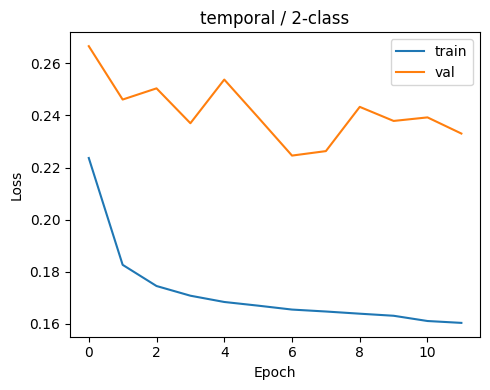

In [ ]:
n_splits = len(SPLITS_TO_RUN)
n_modes = len(MODES_TO_RUN)
fig, axes = plt.subplots(n_splits, n_modes, figsize=(5 * n_modes, 4 * n_splits), squeeze=False)
for i, split_name in enumerate(SPLITS_TO_RUN):
    for j, mode in enumerate(MODES_TO_RUN):
        ax = axes[i][j]
        hist = histories[(split_name, mode)]
        ax.plot(hist['train_loss'], label='train')
        ax.plot(hist['val_loss'], label='val')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.set_title(f'{split_name} / {mode}-class')
        ax.legend()
plt.tight_layout()
plt.show()

---
## Phase 7: Comparison & Reports

In [ ]:
header = f'{"Split":<10}{"Mode":<6}{"Classes":<10}{"Accuracy":<12}{"MacroF1":<12}{"WeightedF1":<14}{"MacroPrec":<12}{"MacroRec":<12}'
print(header)
print('-' * len(header))
for split_name in SPLITS_TO_RUN:
    for mode in MODES_TO_RUN:
        m = results[(split_name, mode)]
        n = len(encoders[(split_name, mode)].classes_)
        print(f'{split_name:<10}{mode:<6}{n:<10}{m["accuracy"]:<12.4f}{m["macro_f1"]:<12.4f}'
              f'{m["weighted_f1"]:<14.4f}{m["macro_precision"]:<12.4f}{m["macro_recall"]:<12.4f}')

Split     Mode  Classes   Accuracy    MacroF1     WeightedF1    MacroPrec   MacroRec    
----------------------------------------------------------------------------------------
temporal  2     2         0.8565      0.6280      0.8983        0.6011      0.9230      


In [ ]:
for split_name in SPLITS_TO_RUN:
    for mode in MODES_TO_RUN:
        print(f'\n===== {split_name} / {mode}-class classification report =====')
        print(results[(split_name, mode)]['report'])


===== temporal / 2-class classification report =====
              precision    recall  f1-score   support

      Attack     0.9998    0.8513    0.9196    619336
      Benign     0.2024    0.9947    0.3364     23497

    accuracy                         0.8565    642833
   macro avg     0.6011    0.9230    0.6280    642833
weighted avg     0.9706    0.8565    0.8983    642833



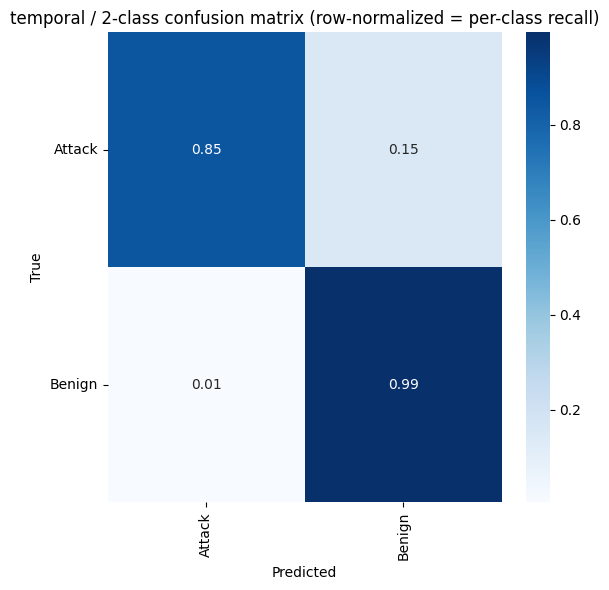

In [ ]:
for split_name in SPLITS_TO_RUN:
    for mode in MODES_TO_RUN:
        cm = results[(split_name, mode)]['confusion_matrix']
        cm_norm = cm.astype(np.float64) / cm.sum(axis=1, keepdims=True).clip(min=1)
        classes = encoders[(split_name, mode)].classes_

        fig_dim = max(6, len(classes) * 0.35)
        plt.figure(figsize=(fig_dim, fig_dim))
        annot = len(classes) <= 12
        sns.heatmap(
            cm_norm, annot=annot, fmt='.2f' if annot else '',
            cmap='Blues', xticklabels=classes, yticklabels=classes, cbar=True,
        )
        plt.title(f'{split_name} / {mode}-class confusion matrix (row-normalized = per-class recall)')
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.xticks(rotation=90)
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

---
## Phase 8: Persist Artifacts

Per-mode model + label encoder; single shared scaler.

In [ ]:
for split_name in SPLITS_TO_RUN:
    joblib.dump(scalers[split_name], MODELS_DIR / f'scaler_{split_name}.joblib')
    print(f'Saved scaler for {split_name}')
    for mode in MODES_TO_RUN:
        key = (split_name, mode)
        torch.save(models[key].state_dict(), MODELS_DIR / f'ids_dnn_{split_name}_{mode}class.pth')
        joblib.dump(encoders[key], MODELS_DIR / f'label_encoder_{split_name}_{mode}class.joblib')
        joblib.dump(
            {'history': histories[key],
             'y_true': results[key]['y_true'],
             'y_pred': results[key]['y_pred']},
            MODELS_DIR / f'run_artifacts_{split_name}_{mode}class.joblib',
        )
        print(f'  Saved {split_name}/{mode}-class model + encoder + run artifacts')

Saved scaler for temporal
  Saved temporal/2-class model + encoder + run artifacts


---
## Phase 8b: Tree Baselines (RandomForest + XGBoost)

A committee will ask whether the MLP actually beats a 5-line sklearn baseline. Train `RandomForestClassifier` and `XGBClassifier` on the **same train/val/test splits** as the MLP, evaluate with the same metrics, and report side-by-side. If the trees match or exceed the MLP, that's a finding worth discussing — not a failure.

Trees are trained on the same scaled features for consistency (scaling is a no-op for tree splits but harmless).

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb


def evaluate_sklearn(model, X_test, y_test, class_names):
    y_pred = model.predict(X_test)
    return {
        'accuracy': accuracy_score(y_test, y_pred),
        'macro_f1': f1_score(y_test, y_pred, average='macro', zero_division=0),
        'weighted_f1': f1_score(y_test, y_pred, average='weighted', zero_division=0),
        'macro_precision': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'macro_recall': recall_score(y_test, y_pred, average='macro', zero_division=0),
        'report': classification_report(y_test, y_pred, target_names=class_names, zero_division=0, digits=4),
        'confusion_matrix': confusion_matrix(y_test, y_pred),
        'y_true': y_test,
        'y_pred': y_pred,
    }


tree_results = {}
tree_models = {}

for split_name in SPLITS_TO_RUN:
    print(f'\n{"=" * 60}\nTREE BASELINES — split: {split_name}\n{"=" * 60}')
    tr_idx, va_idx, te_idx = SPLIT_INDICES[split_name]
    X_train, X_val, X_test, _, _ = fit_preprocess(X_all, tr_idx, va_idx, te_idx)
    y_train_34 = y_all_34[tr_idx]
    y_test_34 = y_all_34[te_idx]

    for mode in MODES_TO_RUN:
        print(f'\n--- {split_name} / {mode}-class ---')
        y_train_s = remap_labels(y_train_34, mode)
        y_test_s = remap_labels(y_test_34, mode)

        le = encoders[(split_name, mode)]
        y_train_enc = le.transform(y_train_s)
        y_test_enc = le.transform(y_test_s)
        class_names = list(le.classes_)

        print('  RandomForest...')
        rf = RandomForestClassifier(
            n_estimators=200, n_jobs=-1, class_weight='balanced',
            random_state=SEED, max_depth=20,
        )
        rf.fit(X_train, y_train_enc)
        rf_metrics = evaluate_sklearn(rf, X_test, y_test_enc, class_names)
        print(f'    acc: {rf_metrics["accuracy"]:.4f} | macro-F1: {rf_metrics["macro_f1"]:.4f}')

        print('  XGBoost...')
        n_classes = len(class_names)
        present = np.unique(y_train_enc)
        weights = compute_class_weight('balanced', classes=present, y=y_train_enc)
        sample_weight = np.ones_like(y_train_enc, dtype=np.float32)
        for cls, w in zip(present, weights):
            sample_weight[y_train_enc == cls] = w

        xgb_clf = xgb.XGBClassifier(
            n_estimators=300, max_depth=8, learning_rate=0.1,
            tree_method='hist', n_jobs=-1, random_state=SEED,
            objective='binary:logistic' if n_classes == 2 else 'multi:softprob',
            eval_metric='logloss' if n_classes == 2 else 'mlogloss',
        )
        xgb_clf.fit(X_train, y_train_enc, sample_weight=sample_weight)
        xgb_metrics = evaluate_sklearn(xgb_clf, X_test, y_test_enc, class_names)
        print(f'    acc: {xgb_metrics["accuracy"]:.4f} | macro-F1: {xgb_metrics["macro_f1"]:.4f}')

        tree_results[(split_name, mode, 'rf')] = rf_metrics
        tree_results[(split_name, mode, 'xgb')] = xgb_metrics
        tree_models[(split_name, mode, 'rf')] = rf
        tree_models[(split_name, mode, 'xgb')] = xgb_clf

    del X_train, X_val, X_test


TREE BASELINES — split: temporal

--- temporal / 2-class ---
  RandomForest...
    acc: 0.8908 | macro-F1: 0.6681
  XGBoost...
    acc: 0.8934 | macro-F1: 0.6718


In [ ]:
header = f'{"Split":<10}{"Mode":<6}{"Model":<6}{"Accuracy":<12}{"MacroF1":<12}{"WeightedF1":<14}{"MacroPrec":<12}{"MacroRec":<12}'
print(header)
print('-' * len(header))
for split_name in SPLITS_TO_RUN:
    for mode in MODES_TO_RUN:
        rows = [
            ('mlp', results[(split_name, mode)]),
            ('rf',  tree_results.get((split_name, mode, 'rf'))),
            ('xgb', tree_results.get((split_name, mode, 'xgb'))),
        ]
        for kind, m in rows:
            if m is None:
                continue
            print(f'{split_name:<10}{mode:<6}{kind:<6}{m["accuracy"]:<12.4f}{m["macro_f1"]:<12.4f}'
                  f'{m["weighted_f1"]:<14.4f}{m["macro_precision"]:<12.4f}{m["macro_recall"]:<12.4f}')
    print()

Split     Mode  Model Accuracy    MacroF1     WeightedF1    MacroPrec   MacroRec    
------------------------------------------------------------------------------------
temporal  2     mlp   0.8565      0.6280      0.8983        0.6011      0.9230      
temporal  2     rf    0.8908      0.6681      0.9201        0.6237      0.9335      
temporal  2     xgb   0.8934      0.6718      0.9218        0.6260      0.9353      



---
## Phase 9: Inference Benchmark

**Latency target:** end-to-end inference under ~100 ms for a single flow on the demo host. This is sufficient for **interactive single-request inference** in the demo (user clicks, sees verdict). It is **not** a line-rate gateway claim — line-rate (10 Gbps / >1M flows/sec) is explicitly out of scope.

For each MLP model, measured at batch sizes `[1, 32, 256, 1024]`:
- **End-to-end latency** including `scaler.transform` (the demo path, not just `model(x)`)
- **p50 / p95 / p99** over 1000 runs per batch size (after 100 warmup runs)
- **Throughput** in flows/sec

`torch.cuda.synchronize()` is called before/after timing on CUDA devices so we measure execution rather than kernel-launch latency.

In [ ]:
BATCH_SIZES = [1, 32, 256, 1024]
N_WARMUP = 100
N_RUNS = 1000


def sync():
    if device.type == 'cuda':
        torch.cuda.synchronize()


def benchmark_model(model, scaler, X_unscaled_pool, batch_size, n_warmup, n_runs):
    """End-to-end latency: scaler.transform + tensor build + model forward."""
    model.eval()
    pool_size = X_unscaled_pool.shape[0]
    rng = np.random.default_rng(SEED)

    def one_pass():
        idx = rng.integers(0, pool_size, size=batch_size)
        raw = X_unscaled_pool[idx]
        scaled = scaler.transform(raw).astype(np.float32)
        x = torch.from_numpy(scaled).to(device, non_blocking=True)
        sync()
        with torch.no_grad():
            _ = model(x)
        sync()

    for _ in range(n_warmup):
        one_pass()

    samples = np.empty(n_runs, dtype=np.float64)
    for i in range(n_runs):
        sync()
        t0 = time.perf_counter()
        one_pass()
        samples[i] = time.perf_counter() - t0

    return {
        'p50_ms': float(np.percentile(samples, 50) * 1000),
        'p95_ms': float(np.percentile(samples, 95) * 1000),
        'p99_ms': float(np.percentile(samples, 99) * 1000),
        'mean_ms': float(samples.mean() * 1000),
        'throughput_flows_per_sec': float(batch_size / samples.mean()),
    }


print(f'{"Split":<10}{"Mode":<6}{"Batch":<8}{"p50 ms":<10}{"p95 ms":<10}{"p99 ms":<10}{"flows/sec":<14}')
print('-' * 70)
for split_name in SPLITS_TO_RUN:
    scaler = scalers[split_name]
    tr_idx, _, _ = SPLIT_INDICES[split_name]
    pool = X_all[tr_idx[:10_000]]
    pool = np.where(np.isnan(pool), 0.0, pool).astype(np.float32)

    for mode in MODES_TO_RUN:
        model = models[(split_name, mode)]
        for bs in BATCH_SIZES:
            stats = benchmark_model(model, scaler, pool, bs, N_WARMUP, N_RUNS)
            print(f'{split_name:<10}{mode:<6}{bs:<8}'
                  f'{stats["p50_ms"]:<10.3f}{stats["p95_ms"]:<10.3f}{stats["p99_ms"]:<10.3f}'
                  f'{stats["throughput_flows_per_sec"]:<14,.0f}')

Split     Mode  Batch   p50 ms    p95 ms    p99 ms    flows/sec     
----------------------------------------------------------------------
temporal  2     1       0.855     2.757     3.809     939           
temporal  2     32      0.794     2.156     2.702     33,379        
temporal  2     256     0.896     2.085     2.690     244,164       
temporal  2     1024    1.018     2.082     2.477     890,964       
